In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import shotchartdetail as sd
from nba_api.stats.static import players
import numpy as np
import seaborn as sb

def FindPlayerData(name):
    plist = players.find_players_by_full_name(name)
    pdict = plist[0]
    response = sd.ShotChartDetail(
    team_id=0,
    player_id= pdict['id'],
    context_measure_simple='FGA',
    season_type_all_star=['Regular Season', 'Playoffs'])
    shot_df = response.get_data_frames()[0]
    return shot_df

def cleandf(df):
    df = df[['LOC_X','LOC_Y','SHOT_MADE_FLAG']]
    df['LOC_X'] = df['LOC_X']/10
    df['LOC_Y'] = df['LOC_Y']/10
    df = df.rename(columns={'LOC_X':'X_Pos','LOC_Y':'Y_Pos', 'SHOT_MADE_FLAG':'FLAG'})
    return df

def shot_Type(df):
    x_make = df[df['FLAG'] == 1]['X_Pos'].tolist()
    y_make = df[df['FLAG'] == 1]['Y_Pos'].tolist()
    x_miss = df[df['FLAG'] == 0]['X_Pos'].tolist()
    y_miss = df[df['FLAG'] == 0]['Y_Pos'].tolist()
    return x_make, y_make, x_miss, y_miss


ModuleNotFoundError: No module named 'pandas'

In [ ]:
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()

    hoop = Circle((0, 0), radius=0.75, linewidth=lw, color=color, fill=False)

    backboard = Rectangle((-3, -0.75), 6, -0.1, linewidth=lw, color=color)

    outer_box = Rectangle((-8, -5.25), 16, 19, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-6, -5.25), 12, 19, linewidth=lw, color=color, fill=False)

    top_free_throw = Arc((0, 13.75), 12, 12, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    bottom_free_throw = Arc((0, 13.75), 12, 12, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')

    restricted = Arc((0, 0), 8, 8, theta1=0, theta2=180, linewidth=lw, color=color)

    corner_three_a = Rectangle((-22, -5.25), 0, 14, linewidth=lw, color=color)
    corner_three_b = Rectangle((22, -5.25), 0, 14, linewidth=lw, color=color)

    three_arc = Arc((0, 0), 47.5, 47.5, theta1=22, theta2=158, linewidth=lw, color=color)

    center_outer = Arc((0, 41.75), 12, 12, theta1=180, theta2=0, linewidth=lw, color=color)
    center_inner = Arc((0, 41.75), 4, 4, theta1=180, theta2=0, linewidth=lw, color=color)

    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer, center_inner]

    for element in court_elements:
        ax.add_patch(element)

    return ax

In [ ]:
def draw_shot_heatmap(df, player_name):
    fig, ax = plt.subplots(figsize=(12, 11))
    draw_court(ax=ax, color='black', lw=2)

    sb.kdeplot(
        x=df['X_Pos'],
        y=df['Y_Pos'],
        fill=True,
        cmap='YlOrRd',
        alpha=0.6,
        bw_adjust=0.4,
        thresh=0.05,
        ax=ax
    )

    ax.set_xlim(-25, 25)
    ax.set_ylim(-5.25, 41.75)
    ax.set_title(f'{player_name} Career Shot Heatmap', fontsize=15)
    ax.set_xlabel('Court Width (ft)')
    ax.set_ylabel('Court Length (ft)')
    plt.show()

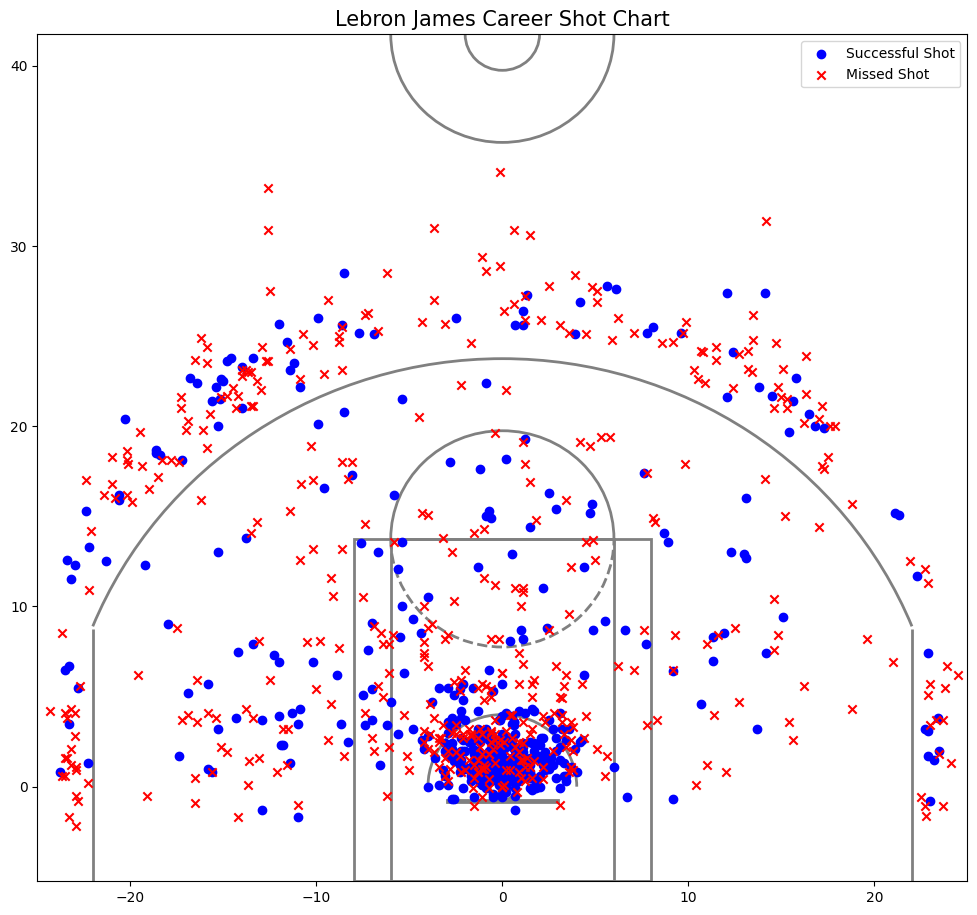

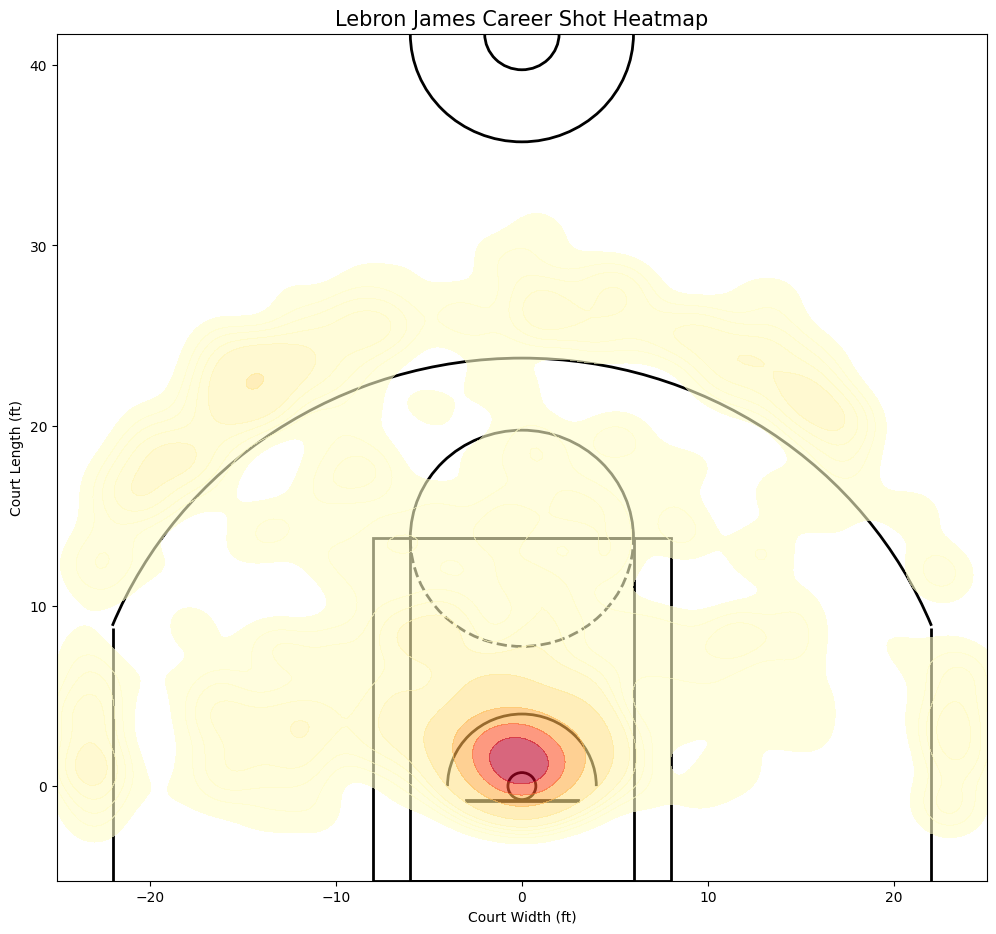

In [ ]:
player_name = 'Lebron James'
df = FindPlayerData('Lebron James')
df = cleandf(df)
x_make, y_make, x_miss, y_miss = shot_Type(df)

plt.figure(figsize=(12, 11))
draw_court(color='gray', lw=2)



plt.scatter(x_make,y_make, marker='o',color='blue',label='Successful Shot')
plt.scatter(x_miss,y_miss, marker='x',color='red',label='Missed Shot')
plt.legend()

plt.xlim(-25, 25)
plt.ylim(-5.25, 41.75)

plt.title(f'{player_name} Career Shot Chart', fontsize=15)
plt.show()


draw_shot_heatmap(df, player_name)